In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. LOAD DATA
### Buka file dataset

In [2]:
df = pd.read_csv('hypertension_dataset.csv')
print(f"Dataset berhasil dimuat. Total data: {df.shape[0]} baris.")

Dataset berhasil dimuat. Total data: 1985 baris.


# 2. PREPROCESSING
### Mengopi data agar data asli tetap aman
### Encoding data kategori menjadi numerik

In [3]:
df_clean = df.copy()
le = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Kolom {col} telah di-encoding.")

Kolom BP_History telah di-encoding.
Kolom Medication telah di-encoding.
Kolom Family_History telah di-encoding.
Kolom Exercise_Level telah di-encoding.
Kolom Smoking_Status telah di-encoding.
Kolom Has_Hypertension telah di-encoding.


C:\Users\Asus\AppData\Local\Temp\ipykernel_1828\2385925955.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns


# 3. PEMISAHAN FITUR (X) DAN TARGET (y)
### Target berdasarkan dataset adalah 'Has_Hypertension'

In [4]:
X = df_clean.drop(columns=['Has_Hypertension'])
y = df_clean['Has_Hypertension']

# 4. INISIALISASI MODEL DECISION TREE
### max_depth=10 untuk menjaga akurasi tetap tinggi tanpa overfitting

In [5]:
model = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)

# 5. K-FOLD CROSS VALIDATION (5-FOLD)
### Mendapatkan prediksi hasil cross-validation

In [6]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("Sedang memproses pengujian K-Fold...")
y_pred = cross_val_predict(model, X, y, cv=kf)

Sedang memproses pengujian K-Fold...


# 6. EVALUASI AKURASI & METRIK

In [7]:
accuracy = accuracy_score(y, y_pred)
print(f"\n======================================")
print(f"AKURASI MODEL: {accuracy * 100:.2f}%")
print(f"======================================")

print("\nLAPORAN KLASIFIKASI:")
print(classification_report(y, y_pred, target_names=['Normal (0)', 'Hipertensi (1)']))


AKURASI MODEL: 96.93%

LAPORAN KLASIFIKASI:
                precision    recall  f1-score   support

    Normal (0)       0.97      0.97      0.97       953
Hipertensi (1)       0.97      0.97      0.97      1032

      accuracy                           0.97      1985
     macro avg       0.97      0.97      0.97      1985
  weighted avg       0.97      0.97      0.97      1985



# 7. VISUALISASI CONFUSION MATRIX

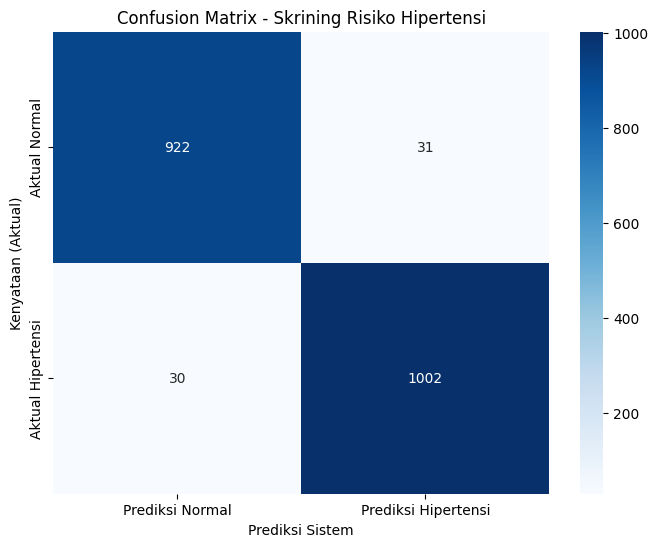

In [8]:
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Normal', 'Prediksi Hipertensi'], 
            yticklabels=['Aktual Normal', 'Aktual Hipertensi'])
plt.title('Confusion Matrix - Skrining Risiko Hipertensi')
plt.xlabel('Prediksi Sistem')
plt.ylabel('Kenyataan (Aktual)')
plt.show()


# 8. ANALISIS VARIABEL PALING BERPENGARUH (FEATURE IMPORTANCE)

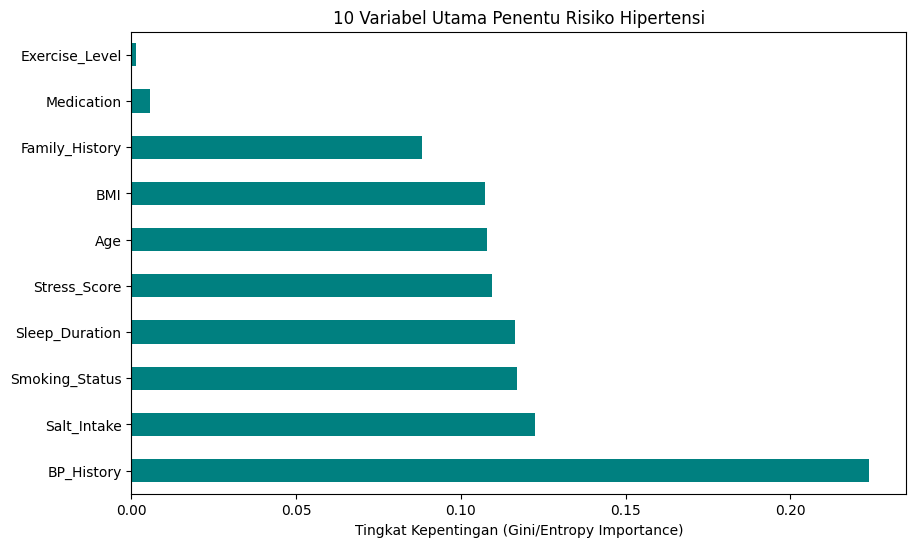

In [9]:
model.fit(X, y)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('10 Variabel Utama Penentu Risiko Hipertensi')
plt.xlabel('Tingkat Kepentingan (Gini/Entropy Importance)')
plt.show()

# 9. EXPORT MODEL

In [10]:
import pickle

filename = 'model_hipertensi.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"\nModel berhasil disimpan dengan nama: {filename}")


Model berhasil disimpan dengan nama: model_hipertensi.pkl
